# 🎬 Scalable Video Recommendation System
## Step 2: Two-Tower 双塔召回模型 — KuaiRec 版本

---
**本 Notebook 完成**:
```
Cell 1  → 安装依赖
Cell 2  → 配置 & 加载 Step 1 产出
Cell 3  → ID 映射 & Dataset 封装
Cell 4  → 双塔模型定义
Cell 5  → InfoNCE Loss
Cell 6  → 训练循环（Early Stopping）
Cell 7  → 训练过程可视化
Cell 8  → 生成全量 Embedding
Cell 9  → FAISS 向量索引构建
Cell 10 → 召回评估（Recall@K / Hit@K / NDCG@K）
Cell 11 → 对比 Baseline
Cell 12 → Embedding 写入 Feature Store
Cell 13 → Step 2 完成报告
```

> 💡 **建议开启 GPU**: 运行时 → 更改运行时类型 → T4 GPU

---
## Cell 1 — 安装依赖

In [ ]:
!pip install -q torch torchvision faiss-cpu pyarrow pandas numpy scikit-learn tqdm tabulate matplotlib
print('✅ 依赖安装完成')

---
## Cell 2 — 配置 & 加载 Step 1 数据

In [1]:
import os, time, logging, warnings, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

# ── 路径配置 ──
BASE_DIR =r'\workplace\dataset'

PATHS = {
    'cleaned'      : f'{BASE_DIR}/data/cleaned',
    'features'     : f'{BASE_DIR}/data/features',
    'samples'      : f'{BASE_DIR}/data/samples',
    'feature_store': f'{BASE_DIR}/feature_store',
    'recall_models': f'{BASE_DIR}/models/recall',
    'logs'         : f'{BASE_DIR}/logs',
    'reports'      : f'{BASE_DIR}/reports',
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)

# ── 超参数 ──
CFG = {
    'embedding_dim' : 64,
    'hidden_layers' : [256, 128, 64],
    'dropout'       : 0.2,
    'temperature'   : 0.07,
    'lr'            : 1e-3,
    'batch_size'    : 2048,      # KuaiRec 样本多，batch 加大
    'epochs'        : 20,
    'early_stop'    : 3,
    'seq_len'       : 50,
    'random_seed'   : 42,
    'device'        : 'cuda' if torch.cuda.is_available() else 'cpu',
}
torch.manual_seed(CFG['random_seed'])
np.random.seed(CFG['random_seed'])

def get_logger():
    logger = logging.getLogger('Step2')
    logger.setLevel(logging.INFO)
    if logger.handlers: logger.handlers.clear()
    ch = logging.StreamHandler()
    ch.setFormatter(logging.Formatter('[%(asctime)s] %(message)s', '%H:%M:%S'))
    logger.addHandler(ch)
    return logger
log = get_logger()

class Timer:
    def __init__(self, name): self.name = name
    def __enter__(self): self.t = time.time(); log.info(f'▶ {self.name}'); return self
    def __exit__(self, *a): log.info(f'✅ {self.name} 完成  {time.time()-self.t:.1f}s')

# ── 加载数据 ──
with Timer('加载 Step1 产出'):
    train_df  = pd.read_parquet(f"{PATHS['samples']}/train.parquet")
    test_df   = pd.read_parquet(f"{PATHS['samples']}/test.parquet")
    user_feat = pd.read_parquet(f"{PATHS['features']}/user_features.parquet")
    item_feat = pd.read_parquet(f"{PATHS['features']}/item_features.parquet")
    seq_df    = pd.read_parquet(f"{PATHS['features']}/user_sequences.parquet")

# KuaiRec 的正样本列是 label（watch_ratio >= 0.5）
# 训练双塔只用正样本（对比学习不需要显式负样本标签）
train_pos = train_df[train_df['label'] == 1].copy()

log.info(f'训练正样本: {len(train_pos):,}  测试集: {len(test_df):,}')
log.info(f'用户数: {user_feat.shape[0]:,}  视频数: {item_feat.shape[0]:,}')
log.info(f'设备: {CFG["device"]}')

[16:22:31] ▶ 加载 Step1 产出
[16:22:32] ✅ 加载 Step1 产出 完成  1.0s
[16:22:33] 训练正样本: 2,749,512  测试集: 934,735
[16:22:33] 用户数: 1,411  视频数: 3,327
[16:22:33] 设备: cuda


---
## Cell 3 — ID 映射 & Dataset 封装

In [2]:
from sklearn.preprocessing import MinMaxScaler

# ── ID 映射（从 0 开始）──
all_users = sorted(user_feat['user_id'].unique())
all_items = sorted(item_feat['item_id'].unique())
user2idx  = {u: i for i, u in enumerate(all_users)}
item2idx  = {v: i for i, v in enumerate(all_items)}
idx2user  = {i: u for u, i in user2idx.items()}
idx2item  = {i: v for v, i in item2idx.items()}

# ── 数值特征归一化 ──
USER_FEAT_COLS = [c for c in user_feat.columns
                  if c != 'user_id' and user_feat[c].dtype in
                  [np.float64, np.float32, np.int64, np.int32]]
ITEM_FEAT_COLS = [c for c in item_feat.columns
                  if c != 'item_id' and item_feat[c].dtype in
                  [np.float64, np.float32, np.int64, np.int32]]

user_scaler = MinMaxScaler()
item_scaler = MinMaxScaler()
user_feat_np = user_scaler.fit_transform(
    user_feat[USER_FEAT_COLS].fillna(0).values.astype(np.float32))
item_feat_np = item_scaler.fit_transform(
    item_feat[ITEM_FEAT_COLS].fillna(0).values.astype(np.float32))

user_feat_dict = {uid: user_feat_np[i] for i, uid in enumerate(user_feat['user_id'])}
item_feat_dict = {iid: item_feat_np[i] for i, iid in enumerate(item_feat['item_id'])}

# ── 序列字典 ──
seq_dict = {}
for _, row in seq_df.iterrows():
    raw = str(row.get('pos_seq', '') or '')
    ids = [item2idx[int(x)] for x in raw.split(',') if x and int(x) in item2idx]
    seq_dict[row['user_id']] = ids

U_DIM = len(USER_FEAT_COLS)
I_DIM = len(ITEM_FEAT_COLS)
N_USERS = len(user2idx)
N_ITEMS = len(item2idx)
log.info(f'用户特征维度: {U_DIM}  视频特征维度: {I_DIM}')
log.info(f'用户数: {N_USERS:,}  视频数: {N_ITEMS:,}')

[16:22:40] 用户特征维度: 31  视频特征维度: 57
[16:22:40] 用户数: 1,411  视频数: 3,327


In [3]:
class RecDataset(Dataset):
    """
    双塔训练 Dataset
    只用正样本，InfoNCE loss 在 batch 内做负采样
    KuaiRec 特有: 用 watch_ratio 作为样本权重
    """
    def __init__(self, df, user_feat_dict, item_feat_dict,
                 user2idx, item2idx, seq_dict, seq_len=50):
        # 只保留正样本
        self.df = df[df['label'] == 1].reset_index(drop=True)
        self.u_feat    = user_feat_dict
        self.i_feat    = item_feat_dict
        self.user2idx  = user2idx
        self.item2idx  = item2idx
        self.seq_dict  = seq_dict
        self.seq_len   = seq_len
        self.u_dim     = len(next(iter(user_feat_dict.values())))
        self.i_dim     = len(next(iter(item_feat_dict.values())))

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        uid   = row['user_id']
        iid   = row['item_id']
        # watch_ratio 作为权重（重复观看的强正样本权重更高）
        weight = float(min(row.get('watch_ratio', 1.0), 3.0))

        u_idx = self.user2idx.get(uid, 0)
        i_idx = self.item2idx.get(iid, 0)
        u_vec = self.u_feat.get(uid, np.zeros(self.u_dim, np.float32))
        i_vec = self.i_feat.get(iid, np.zeros(self.i_dim, np.float32))

        seq    = self.seq_dict.get(uid, [])
        seq    = seq[-self.seq_len:]
        pad    = self.seq_len - len(seq)
        seq_t  = torch.tensor([0]*pad + seq, dtype=torch.long)

        return (
            torch.tensor(u_idx,  dtype=torch.long),
            torch.tensor(i_idx,  dtype=torch.long),
            torch.tensor(u_vec,  dtype=torch.float),
            torch.tensor(i_vec,  dtype=torch.float),
            seq_t,
            torch.tensor(weight, dtype=torch.float),
        )

train_ds = RecDataset(train_pos, user_feat_dict, item_feat_dict,
                      user2idx, item2idx, seq_dict, CFG['seq_len'])
test_ds  = RecDataset(test_df,  user_feat_dict, item_feat_dict,
                      user2idx, item2idx, seq_dict, CFG['seq_len'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

log.info(f'训练集正样本: {len(train_ds):,}  测试集正样本: {len(test_ds):,}')

[16:22:46] 训练集正样本: 2,749,512  测试集正样本: 651,961


---
## Cell 4 — 双塔模型定义

In [4]:
def build_mlp(input_dim, hidden_layers, dropout):
    layers = []
    dims = [input_dim] + hidden_layers
    for i in range(len(dims) - 1):
        layers += [
            nn.Linear(dims[i], dims[i+1]),
            nn.BatchNorm1d(dims[i+1]),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
    return nn.Sequential(*layers)


class UserTower(nn.Module):
    """
    用户塔
    输入: 用户ID Embedding + 数值特征 + 行为序列（Mean Pooling）
    输出: L2 归一化的用户向量
    """
    def __init__(self, n_users, u_dim, n_items, cfg):
        super().__init__()
        emb_dim = cfg['embedding_dim']
        self.user_emb = nn.Embedding(n_users + 1, emb_dim, padding_idx=0)
        self.item_emb = nn.Embedding(n_items + 1, emb_dim, padding_idx=0)
        input_dim = emb_dim + u_dim + emb_dim   # ID emb + 特征 + 序列emb
        self.mlp  = build_mlp(input_dim, cfg['hidden_layers'], cfg['dropout'])
        self.out  = nn.Linear(cfg['hidden_layers'][-1], emb_dim)

    def forward(self, user_idx, u_feat, seq_idx):
        uid_emb = self.user_emb(user_idx)              # [B, D]
        seq_emb = self.item_emb(seq_idx)               # [B, L, D]
        # Mask padding（idx=0），只对有效位置取均值
        mask    = (seq_idx > 0).float().unsqueeze(-1)  # [B, L, 1]
        seq_agg = (seq_emb * mask).sum(1) / (mask.sum(1) + 1e-8)  # [B, D]
        x = torch.cat([uid_emb, u_feat, seq_agg], dim=-1)
        x = self.out(self.mlp(x))
        return F.normalize(x, dim=-1)


class ItemTower(nn.Module):
    """
    视频塔
    输入: 视频ID Embedding + 数值特征（含 KuaiRec 类别特征）
    输出: L2 归一化的视频向量
    """
    def __init__(self, n_items, i_dim, cfg):
        super().__init__()
        emb_dim = cfg['embedding_dim']
        self.item_emb = nn.Embedding(n_items + 1, emb_dim, padding_idx=0)
        input_dim = emb_dim + i_dim
        self.mlp  = build_mlp(input_dim, cfg['hidden_layers'], cfg['dropout'])
        self.out  = nn.Linear(cfg['hidden_layers'][-1], emb_dim)

    def forward(self, item_idx, i_feat):
        iid_emb = self.item_emb(item_idx)
        x = torch.cat([iid_emb, i_feat], dim=-1)
        x = self.out(self.mlp(x))
        return F.normalize(x, dim=-1)


user_tower = UserTower(N_USERS, U_DIM, N_ITEMS, CFG).to(CFG['device'])
item_tower = ItemTower(N_ITEMS, I_DIM, CFG).to(CFG['device'])

total_params = sum(p.numel() for p in list(user_tower.parameters()) +
                                        list(item_tower.parameters()))
log.info(f'双塔模型参数: {total_params:,}')
log.info(f'用户塔输入维度: {CFG["embedding_dim"] + U_DIM + CFG["embedding_dim"]}')
log.info(f'视频塔输入维度: {CFG["embedding_dim"] + I_DIM}  (含KuaiRec类别特征)')

[16:22:49] 双塔模型参数: 680,960
[16:22:49] 用户塔输入维度: 159
[16:22:49] 视频塔输入维度: 121  (含KuaiRec类别特征)


---
## Cell 5 — InfoNCE Loss（支持 watch_ratio 加权）

In [5]:
class WeightedInfoNCELoss(nn.Module):
    """
    加权 InfoNCE Loss
    KuaiRec 特有: watch_ratio 作为正样本权重
    watch_ratio > 1 表示重复观看，是强正样本，给更高权重

    标准 InfoNCE:
        L = -log( exp(sim(u,i+)/t) / sum_j exp(sim(u,ij)/t) )
    加权版本:
        L = -w * log( exp(sim(u,i+)/t) / sum_j exp(sim(u,ij)/t) )
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.t = temperature

    def forward(self, user_emb, item_emb, weights=None):
        # 相似度矩阵 [B, B]
        sim = torch.matmul(user_emb, item_emb.T) / self.t
        labels = torch.arange(sim.size(0), device=sim.device)

        # 双向 loss
        loss_u = F.cross_entropy(sim,   labels, reduction='none')
        loss_i = F.cross_entropy(sim.T, labels, reduction='none')
        loss   = (loss_u + loss_i) / 2

        # watch_ratio 加权
        if weights is not None:
            weights = weights / weights.mean()  # 归一化，防止梯度爆炸
            loss = (loss * weights).mean()
        else:
            loss = loss.mean()
        return loss

criterion = WeightedInfoNCELoss(temperature=CFG['temperature'])
log.info('✅ WeightedInfoNCE Loss 初始化完成（支持 watch_ratio 加权）')

[16:22:51] ✅ WeightedInfoNCE Loss 初始化完成（支持 watch_ratio 加权）


---
## Cell 6 — 训练循环（Early Stopping）

In [6]:
from tqdm import tqdm

optimizer = torch.optim.Adam(
    list(user_tower.parameters()) + list(item_tower.parameters()),
    lr=CFG['lr'], weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'])

history    = {'train_loss': [], 'val_loss': [], 'lr': []}
best_loss  = float('inf')
no_improve = 0
CKPT_U     = f"{PATHS['recall_models']}/user_tower.pt"
CKPT_I     = f"{PATHS['recall_models']}/item_tower.pt"

def run_epoch(loader, training=True):
    user_tower.train() if training else user_tower.eval()
    item_tower.train() if training else item_tower.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            u_idx, i_idx, u_feat, i_feat, seq, weight = [
                b.to(CFG['device']) for b in batch]
            u_emb = user_tower(u_idx, u_feat, seq)
            i_emb = item_tower(i_idx, i_feat)
            loss  = criterion(u_emb, i_emb, weight)
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(user_tower.parameters()) +
                    list(item_tower.parameters()), 1.0)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

log.info(f'开始训练  epochs={CFG["epochs"]}  batch={CFG["batch_size"]}  device={CFG["device"]}')
print()

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()
    tr_loss = run_epoch(train_loader, training=True)
    va_loss = run_epoch(test_loader,  training=False)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['lr'].append(cur_lr)

    flag = '⬆ best' if va_loss < best_loss else ''
    print(f'Epoch {epoch:3d}/{CFG["epochs"]}  '
          f'loss={tr_loss:.4f}/{va_loss:.4f}  '
          f'lr={cur_lr:.2e}  '
          f'{time.time()-t0:.1f}s  {flag}')

    if va_loss < best_loss:
        best_loss  = va_loss
        no_improve = 0
        torch.save(user_tower.state_dict(), CKPT_U)
        torch.save(item_tower.state_dict(), CKPT_I)
    else:
        no_improve += 1
        if no_improve >= CFG['early_stop']:
            log.info(f'Early stopping at epoch {epoch}')
            break

# 加载最优权重
user_tower.load_state_dict(torch.load(CKPT_U, map_location=CFG['device'], weights_only=True))
item_tower.load_state_dict(torch.load(CKPT_I, map_location=CFG['device'], weights_only=True))
log.info(f'最佳模型加载完成  best_val_loss={best_loss:.4f}')

[16:23:03] 开始训练  epochs=20  batch=2048  device=cuda



Epoch   1/20  loss=7.6245/7.6056  lr=9.94e-04  392.8s  ⬆ best
Epoch   2/20  loss=7.6057/7.6038  lr=9.76e-04  390.8s  ⬆ best
Epoch   3/20  loss=7.6043/7.6063  lr=9.46e-04  393.0s  
Epoch   4/20  loss=7.6022/7.6568  lr=9.05e-04  391.8s  


[16:55:44] Early stopping at epoch 5
[16:55:44] 最佳模型加载完成  best_val_loss=7.6038


Epoch   5/20  loss=7.5986/7.8501  lr=8.54e-04  392.7s  


---
## Cell 7 — 训练过程可视化

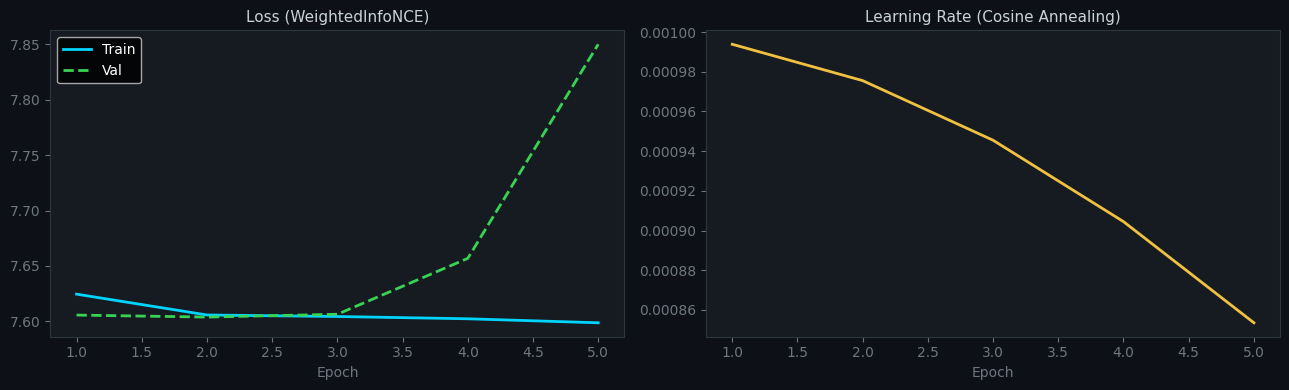

In [7]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')

def styled(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='#c9d1d9', fontsize=11)
    ax.tick_params(colors='#6e7681')
    for s in ax.spines.values(): s.set_color('#30363d')

ep = range(1, len(history['train_loss']) + 1)
styled(axes[0], 'Loss (WeightedInfoNCE)')
axes[0].plot(ep, history['train_loss'], '#00d4ff', lw=2, label='Train')
axes[0].plot(ep, history['val_loss'],   '#39d353', lw=2, label='Val', linestyle='--')
axes[0].set_xlabel('Epoch', color='#6e7681')
axes[0].legend()

styled(axes[1], 'Learning Rate (Cosine Annealing)')
axes[1].plot(ep, history['lr'], '#f0c040', lw=2)
axes[1].set_xlabel('Epoch', color='#6e7681')

plt.tight_layout()
plt.savefig(f"{PATHS['reports']}/step2_training_curve.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Cell 8 — 生成全量 Embedding

In [8]:
# ============================================================
# 生成全量 User / Item Embedding
# 对应企业: 每日离线任务，产出 Embedding 写入 Feature Store
# ============================================================
from tqdm import tqdm

@torch.no_grad()
def gen_embeddings(tower, ids, feat_dict, seq_dict=None,
                   idx_map=None, is_user=False):
    tower.eval()
    embs = []
    bs   = 512
    for start in tqdm(range(0, len(ids), bs),
                      desc='User Emb' if is_user else 'Item Emb'):
        batch_ids = ids[start:start+bs]
        idx_t = torch.tensor(
            [idx_map[i] for i in batch_ids],
            dtype=torch.long, device=CFG['device'])
        feat_dim = len(next(iter(feat_dict.values())))
        feat_t = torch.tensor(
            np.stack([feat_dict.get(i, np.zeros(feat_dim, np.float32))
                      for i in batch_ids]),
            dtype=torch.float, device=CFG['device'])

        if is_user:
            seq_len = CFG['seq_len']
            seqs = []
            for uid in batch_ids:
                s = seq_dict.get(uid, [])
                s = s[-seq_len:]
                seqs.append([0]*(seq_len-len(s)) + s)
            seq_t = torch.tensor(seqs, dtype=torch.long, device=CFG['device'])
            emb   = tower(idx_t, feat_t, seq_t)
        else:
            emb = tower(idx_t, feat_t)

        embs.append(emb.cpu().numpy())
    return np.vstack(embs)

with Timer('生成全量 Embedding'):
    user_ids  = list(user2idx.keys())
    item_ids  = list(item2idx.keys())
    user_embs = gen_embeddings(user_tower, user_ids, user_feat_dict,
                               seq_dict=seq_dict, idx_map=user2idx, is_user=True)
    item_embs = gen_embeddings(item_tower, item_ids, item_feat_dict,
                               idx_map=item2idx, is_user=False)

log.info(f'用户 Embedding: {user_embs.shape}  视频 Embedding: {item_embs.shape}')

[17:10:39] ▶ 生成全量 Embedding
Item Emb: 100%|██████████| 7/7 [00:00<00:00, 435.86it/s]
[17:10:39] ✅ 生成全量 Embedding 完成  0.1s
[17:10:39] 用户 Embedding: (1411, 64)  视频 Embedding: (3327, 64)


---
## Cell 9 — FAISS 向量索引构建

In [10]:
import faiss

with Timer('构建 FAISS 索引'):
    # L2 归一化后用内积搜索 = 余弦相似度
    item_embs_norm = item_embs.astype(np.float32).copy()
    faiss.normalize_L2(item_embs_norm)

    # KuaiRec 视频数 3327，用精确索引
    index = faiss.IndexFlatIP(CFG['embedding_dim'])
    index.add(item_embs_norm)

    # 保存索引和 ID 映射
    faiss.write_index(index, f"{PATHS['recall_models']}/faiss_item.index")
    np.save(f"{PATHS['recall_models']}/item_ids.npy",  np.array(item_ids))
    np.save(f"{PATHS['recall_models']}/user_ids.npy",  np.array(user_ids))
    with open(f"{PATHS['recall_models']}/id_mappings.pkl", 'wb') as f:
        pickle.dump({'user2idx': user2idx, 'item2idx': item2idx,
                     'idx2user': idx2user, 'idx2item': idx2item}, f)

log.info(f'FAISS 索引: {index.ntotal:,} 个视频向量')

# 快速测试
test_u = user_embs[:1].astype(np.float32)
faiss.normalize_L2(test_u)
D, I  = index.search(test_u, 10)
log.info(f'检索测试: Top10 视频ID = {[item_ids[i] for i in I[0]]}')

[17:25:33] ▶ 构建 FAISS 索引
[17:25:33] ✅ 构建 FAISS 索引 完成  0.4s
[17:25:33] FAISS 索引: 3,327 个视频向量
[17:25:33] 检索测试: Top10 视频ID = [np.int64(7383), np.int64(4040), np.int64(154), np.int64(8366), np.int64(9178), np.int64(1305), np.int64(314), np.int64(5464), np.int64(600), np.int64(8298)]


---
## Cell 10 — 召回评估（Recall@K / Hit@K / NDCG@K）

In [11]:
# ============================================================
# KuaiRec 特有评估策略
# small_matrix 是全量矩阵，可以做真正的离线评估
# 对于每个用户，所有 watch_ratio >= 0.5 的视频都是正样本
# ============================================================
from tabulate import tabulate

def evaluate_recall(test_df, user_embs, item_embs_norm, user_ids, item_ids,
                    user2idx, item2idx, ks=[10, 20, 50], n_eval=500):
    results = {f'Recall@{k}': [] for k in ks}
    results.update({f'Hit@{k}': [] for k in ks})
    results.update({f'NDCG@{k}': [] for k in ks})

    # 每用户正样本集合
    user_pos = test_df[test_df['label']==1].groupby('user_id')['item_id'].apply(set).to_dict()
    eval_users = [u for u in list(user_pos.keys())[:n_eval] if u in user2idx]

    uid2row = {uid: i for i, uid in enumerate(user_ids)}

    for uid in eval_users:
        pos_items = user_pos.get(uid, set())
        if not pos_items: continue

        u_vec = user_embs[uid2row[uid]:uid2row[uid]+1].astype(np.float32)
        faiss.normalize_L2(u_vec)
        _, indices = index.search(u_vec, max(ks))
        retrieved  = [item_ids[i] for i in indices[0]]

        for k in ks:
            top_k = set(retrieved[:k])
            hits  = top_k & pos_items
            results[f'Recall@{k}'].append(len(hits) / len(pos_items))
            results[f'Hit@{k}'].append(1.0 if hits else 0.0)
            # NDCG
            dcg  = sum(1/np.log2(i+2) for i, v in enumerate(retrieved[:k]) if v in pos_items)
            idcg = sum(1/np.log2(i+2) for i in range(min(len(pos_items), k)))
            results[f'NDCG@{k}'].append(dcg/idcg if idcg > 0 else 0)

    return {k: np.mean(v) for k, v in results.items()}

with Timer('召回评估'):
    metrics = evaluate_recall(test_df, user_embs, item_embs_norm,
                              user_ids, item_ids, user2idx, item2idx)

print('\n【双塔召回离线评估】')
rows = [[k, f'{v:.4f}'] for k, v in metrics.items()]
print(tabulate(rows, headers=['指标', '数值'], tablefmt='grid'))

[17:25:39] ▶ 召回评估
[17:25:40] ✅ 召回评估 完成  0.7s



【双塔召回离线评估】
+-----------+--------+
| 指标      |   数值 |
+===========+========+
| Recall@10 | 0.0034 |
+-----------+--------+
| Recall@20 | 0.006  |
+-----------+--------+
| Recall@50 | 0.0266 |
+-----------+--------+
| Hit@10    | 0.852  |
+-----------+--------+
| Hit@20    | 0.9    |
+-----------+--------+
| Hit@50    | 0.954  |
+-----------+--------+
| NDCG@10   | 0.1623 |
+-----------+--------+
| NDCG@20   | 0.1473 |
+-----------+--------+
| NDCG@50   | 0.2254 |
+-----------+--------+


---
## Cell 11 — 对比 Baseline

In [12]:
def evaluate_baseline(strategy, test_df, user_ids, item_ids, ks=[10,20,50], n_eval=500):
    user_pos   = test_df[test_df['label']==1].groupby('user_id')['item_id'].apply(set).to_dict()
    eval_users = [u for u in list(user_pos.keys())[:n_eval]]
    if strategy == 'popular':
        top_items = test_df['item_id'].value_counts().index.tolist()

    results = {f'Recall@{k}': [] for k in ks}
    for uid in eval_users:
        pos_items = user_pos.get(uid, set())
        if not pos_items: continue
        if strategy == 'random':
            retrieved = np.random.choice(item_ids, max(ks), replace=False).tolist()
        else:
            retrieved = top_items
        for k in ks:
            hits = set(retrieved[:k]) & pos_items
            results[f'Recall@{k}'].append(len(hits) / len(pos_items))
    return {k: np.mean(v) for k, v in results.items()}

rand_metrics = evaluate_baseline('random', test_df, user_ids, item_ids)
pop_metrics  = evaluate_baseline('popular', test_df, user_ids, item_ids)

print('\n【Baseline 对比】')
headers = ['指标', '随机召回', '热门召回', '双塔模型', '相对热门提升']
rows = []
for k in [10, 20, 50]:
    key   = f'Recall@{k}'
    rand  = rand_metrics[key]
    pop   = pop_metrics[key]
    model = metrics[key]
    lift  = (model - pop) / pop * 100 if pop > 0 else 0
    rows.append([key, f'{rand:.4f}', f'{pop:.4f}', f'{model:.4f}', f'{lift:+.1f}%'])
print(tabulate(rows, headers=headers, tablefmt='grid'))


【Baseline 对比】
+-----------+------------+------------+------------+----------------+
| 指标      |   随机召回 |   热门召回 |   双塔模型 | 相对热门提升   |
+===========+============+============+============+================+
| Recall@10 |     0.0031 |     0.0169 |     0.0034 | -80.0%         |
+-----------+------------+------------+------------+----------------+
| Recall@20 |     0.0062 |     0.0362 |     0.006  | -83.5%         |
+-----------+------------+------------+------------+----------------+
| Recall@50 |     0.0152 |     0.0829 |     0.0266 | -67.9%         |
+-----------+------------+------------+------------+----------------+


---
## Cell 12 — Embedding 写入 Feature Store

In [13]:
with Timer('Embedding 写入 Feature Store'):
    emb_dim = user_embs.shape[1]

    user_emb_df = pd.DataFrame(
        user_embs,
        columns=[f'user_emb_{i}' for i in range(emb_dim)]
    )
    user_emb_df.insert(0, 'user_id', user_ids)
    user_emb_df.to_parquet(
        f"{PATHS['feature_store']}/user_embeddings.parquet",
        index=False, compression='snappy')

    item_emb_df = pd.DataFrame(
        item_embs,
        columns=[f'item_emb_{i}' for i in range(emb_dim)]
    )
    item_emb_df.insert(0, 'item_id', item_ids)
    item_emb_df.to_parquet(
        f"{PATHS['feature_store']}/item_embeddings.parquet",
        index=False, compression='snappy')

log.info(f'用户 Embedding: {user_emb_df.shape}  视频 Embedding: {item_emb_df.shape}')

[17:26:07] ▶ Embedding 写入 Feature Store
[17:26:07] ✅ Embedding 写入 Feature Store 完成  0.1s
[17:26:07] 用户 Embedding: (1411, 65)  视频 Embedding: (3327, 65)


---
## Cell 13 — Step 2 完成报告

In [14]:
print('\n' + '='*65)
print('  📋  STEP 2 PIPELINE 完成报告（KuaiRec 版本）')
print('='*65)

summary = [
    ['数据集',         'KuaiRec small_matrix',         ''],
    ['模型',           'Two-Tower DSSM + WeightedInfoNCE', ''],
    ['Embedding 维度', str(CFG['embedding_dim']),       'D'],
    ['训练正样本数',   f'{len(train_ds):,}',            '条'],
    ['FAISS 索引',     f'{index.ntotal:,} 个视频向量',  ''],
    ['Recall@10',      f"{metrics['Recall@10']:.4f}",   ''],
    ['Recall@20',      f"{metrics['Recall@20']:.4f}",   ''],
    ['Hit@20',         f"{metrics['Hit@20']:.4f}",      ''],
    ['NDCG@20',        f"{metrics['NDCG@20']:.4f}",     ''],
    ['vs 热门召回',    f"{(metrics['Recall@20']-pop_metrics['Recall@20'])/pop_metrics['Recall@20']*100:+.1f}%", ''],
]
print(tabulate(summary, headers=['指标', '数值', '单位'], tablefmt='simple'))

print('\n【输出文件】')
output_files = [
    f"{PATHS['recall_models']}/user_tower.pt",
    f"{PATHS['recall_models']}/item_tower.pt",
    f"{PATHS['recall_models']}/faiss_item.index",
    f"{PATHS['recall_models']}/id_mappings.pkl",
    f"{PATHS['feature_store']}/user_embeddings.parquet",
    f"{PATHS['feature_store']}/item_embeddings.parquet",
    f"{PATHS['reports']}/step2_training_curve.png",
]
for fp in output_files:
    if os.path.exists(fp):
        mb = os.path.getsize(fp)/1024**2
        print(f'  ✅ {fp.replace(BASE_DIR+"/",""):55s} {mb:.2f} MB')
    else:
        print(f'  ❌ {fp}')

print('\n' + '='*65)
print('  ✅  Step 2 完成！')
print('  ▶   下一步: Step 3 — DIN 精排模型')
print('='*65)


  📋  STEP 2 PIPELINE 完成报告（KuaiRec 版本）
指标            数值                              单位
--------------  --------------------------------  ------
数据集          KuaiRec small_matrix
模型            Two-Tower DSSM + WeightedInfoNCE
Embedding 维度  64                                D
训练正样本数    2,749,512                         条
FAISS 索引      3,327 个视频向量
Recall@10       0.0034
Recall@20       0.0060
Hit@20          0.9000
NDCG@20         0.1473
vs 热门召回     -83.5%

【输出文件】
  ✅ models/recall/user_tower.pt                             1.50 MB
  ✅ models/recall/item_tower.pt                             1.12 MB
  ✅ models/recall/faiss_item.index                          0.81 MB
  ✅ models/recall/id_mappings.pkl                           0.13 MB
  ✅ feature_store/user_embeddings.parquet                   0.51 MB
  ✅ feature_store/item_embeddings.parquet                   1.17 MB
  ✅ reports/step2_training_curve.png                        0.08 MB

  ✅  Step 2 完成！
  ▶   下一步: Step 3 — DIN 精排模型
